<a href="https://colab.research.google.com/github/suganyamuralikarthik/Social-Media-Analysis-Using-Python/blob/main/pythonforanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Social Media Engagement Analytics Using Python**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#  Task 1 — Data Import & Setup

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/social_media_engagement_5000.csv")

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
df.tail().T

,4995,4996,4997,4998,4999
user_id,59500,22100,67021,29800,73400
age,44.0,38.0,63.0,13.0,54.0
gender,Male,Other,Female,Female,Other
country,Australia,UAE,USA,Germany,Japan
post_id,441541,677076,273595,785644,712252
post_type,video,reel,text,video,text
post_category,education,education,travel,fitness,travel
likes,16210.0,16924.0,13487.0,16894.0,14830.0
comments,2013.0,2734.0,NaN,1289.0,503.0
shares,1837.0,1583.0,167.0,1713.0,1798.0


In [ ]:
df.shape

(5000, 19)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029


In [ ]:
df.describe(include='object')

,gender,country,post_type,post_category,posted_at,device_type,sentiment,hashtags
count,4850,5000,5000,5000,5000,5000,4850,5000
unique,3,10,4,8,729,3,3,761
top,Male,India,reel,fitness,26-12-2023,mobile,positive,#tech
freq,1699,535,1283,675,16,1684,2363,201


In [30]:
#Convert date to datetime
df["posted_at"] = pd.to_datetime(df["posted_at"],errors='coerce')
df["posted_at"].dtype

/tmp/ipykernel_2435/499530463.py:2: UserWarning:

Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



dtype('<M8[ns]')

# Task 2 — Data Cleaning

In [ ]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
missing_value =df.isnull().sum()
missing_value[missing_value>0]

,0
age,150
gender,150
likes,150
comments,150
shares,150
sentiment,150


In [ ]:
# Cleaning Missing Data
df['age']=df['age'].fillna(df['age'].median())

In [ ]:
df['gender']=df['gender'].fillna(df['gender'].mode()[0])

In [ ]:
df['likes']=df['likes'].fillna(df['likes'].median())

In [ ]:
df['comments']=df['comments'].fillna(df['comments'].median())

In [ ]:
df['shares']=df['shares'].fillna(df['shares'].median())

In [ ]:
df['sentiment']=df['sentiment'].fillna(df['sentiment'].mode()[0])

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]

print(outliers['age'])

Series([], Name: age, dtype: float64)


In [ ]:
Q1 = df['engagement_rate'].quantile(0.25)
Q3 = df['engagement_rate'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['engagement_rate'] < lower) | (df['engagement_rate'] > upper)]

print(outliers['engagement_rate'])

4        2.777372
11      12.381057
13      48.894602
14       3.144882
19       4.456991
          ...    
4966     1.895782
4969     3.021546
4986    13.013830
4994     1.105746
4999     1.203527
Name: engagement_rate, Length: 578, dtype: float64


In [ ]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)
print("Number of outliers:", len(outliers))

Q1: 0.14578108750000002
Q3: 0.504793702
IQR: 0.35901261449999994
Lower: -0.3927378342499999
Upper: 1.04331262375
Number of outliers: 578


In [ ]:
df['log_engagement_rate'] = np.log1p(df['engagement_rate'])

In [ ]:
df[['engagement_rate', 'log_engagement_rate']].skew()

,0
engagement_rate,18.781271
log_engagement_rate,4.091482


In [ ]:
df.shape

(5000, 20)

In [ ]:
#Duplicate Handling-
df.duplicated().sum()

np.int64(0)

In [ ]:
#Data Formatting
(df['likes'] < 0).sum()
(df['comments'] < 0).sum()
(df['shares'] < 0).sum()

np.int64(0)

In [ ]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [ ]:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [ ]:
# Clean sentiment labels
df['sentiment'] = df['sentiment'].str.strip().str.lower()
df['sentiment'].value_counts()

,count
sentiment,
positive,2513
neutral,1527
negative,960


**Task 3 — Data Exploration using Pandas**

In [ ]:
# ● Analyze categorical distributions using value_counts(), unique(), and nunique().
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['gender', 'country', 'post_type', 'post_category', 'posted_at',
       'device_type', 'sentiment', 'hashtags'],
      dtype='object')


In [ ]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [ ]:
df['post_category'].unique()

array(['fitness', 'food', 'tech', 'travel', 'fashion', 'lifestyle',
       'education', 'music'], dtype=object)

In [ ]:
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print()

In [ ]:
for col in categorical_cols:
    print(col, ":", df[col].nunique())

gender : 3
country : 10
post_type : 4
post_category : 8
posted_at : 729
device_type : 3
sentiment : 3
hashtags : 761


In [ ]:
df['gender'].value_counts()

,count
gender,
Male,1699
Other,1581
Female,1570


In [ ]:
df['gender'].value_counts()
df['country'].value_counts()
df['post_type'].value_counts()
df['post_category'].value_counts()
df['posted_at'].value_counts()
df['device_type'].value_counts()
df['sentiment'].value_counts()
df['hashtags'].value_counts()

In [ ]:
for col in categorical_cols:
    print(col, ":", df[col].nunique())

gender : 3
country : 10
post_type : 4
post_category : 8
posted_at : 729
device_type : 3
sentiment : 3
hashtags : 761


In [ ]:
df['gender'].nunique()
df['country'].nunique()
df['post_type'].nunique()
df['post_category'].nunique()
df['posted_at'].nunique()
df['device_type'].nunique()
df['sentiment'].nunique()
df['hashtags'].nunique()

761

In [ ]:
#Create a correlation matrix for numeric fields.
numeric_cols = [
    'age',
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'follower_count',
    'engagement_rate'
]

In [ ]:
correlation_matrix = df[numeric_cols].corr()
correlation_matrix

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
age,1.000000,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039
likes,-0.036322,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520
comments,-0.007284,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051
shares,0.013871,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724
watch_time_sec,0.005542,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148
impression_count,0.013322,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226
follower_count,-0.024894,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292
engagement_rate,0.008039,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000


In [ ]:
# Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country)
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [ ]:
df.groupby('country')['impression_count'].mean()

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [ ]:
df.groupby('post_category')['likes'].mean()

,likes
post_category,
education,10126.487322
fashion,9843.356902
fitness,9914.602222
food,10225.522766
lifestyle,10180.559308
music,10205.749606
tech,10171.571429
travel,10196.304167


In [ ]:
df.groupby('sentiment')['engagement_rate'].mean()

,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.919744


**Task 4 — Data Wrangling**

###Use merge, concat, or join if combining DataFrames

In [ ]:
df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [ ]:
country_info = pd.DataFrame({
    'country': ['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'],
    'region' : ['South America', 'Europe', 'Europe', 'North America',
               'Asia', 'Oceania', 'Asia', 'Middle East',
               'Europe', 'North America']

})
country_info

,country,region
0,Brazil,South America
1,UK,Europe
2,France,Europe
3,Canada,North America
4,Japan,Asia
5,Australia,Oceania
6,India,Asia
7,UAE,Middle East
8,Germany,Europe
9,USA,North America


In [ ]:
df.merge(country_info,on='country',how='inner').head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,region
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862,South America
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493,South America
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345,Europe
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195,Europe
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372,Europe


In [ ]:
df.merge(country_info,on='country',how='left').head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,region
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862,South America
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493,South America
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345,Europe
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195,Europe
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372,Europe


In [ ]:
df1 = df.set_index('user_id')
df1.head()

,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
user_id,,,,,,,,,,,,,,,,,,
25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
df2=df[['user_id','age','gender']].set_index('user_id')
df2.head()

,age,gender
user_id,,
25795,43.0,Female
10860,33.0,Male
86820,32.0,Female
64886,51.0,Other
16265,34.0,Other


In [ ]:
joined_df = df1.join(df2,lsuffix='_left',rsuffix='_right')
joined_df.head()

,age_left,gender_left,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,age_right,gender_right
user_id,,,,,,,,,,,,,,,,,,,,
25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862,43.0,Female
10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493,33.0,Male
86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345,32.0,Female
64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195,51.0,Other
16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372,34.0,Other


####Create new fields such as engagement_score, log-transformed metric(optional), and hashtag count.

In [19]:
# engagement_score
df['engagement_score'] = (df['likes']+df['comments']+df['shares'])
df[['likes','comments','shares','engagement_score']].head().T

,0,1,2,3,4
likes,7011.0,11750.0,4862.0,5350.0,12682.0
comments,354.0,2606.0,344.0,1083.0,2735.0
shares,1157.0,1807.0,955.0,1049.0,1300.0
engagement_score,8522.0,16163.0,6161.0,7482.0,16717.0


In [ ]:
# log-transformed metrics
df['log_likes']=np.log1p(df['likes'])
df['log_comments']=np.log1p(df['comments'])
df['log_shares']=np.log1p(df['shares'])
df[['likes','log_likes','comments','log_comments','shares','log_shares']].head()

,likes,log_likes,comments,log_comments,shares,log_shares
0,7011.0,8.855378,354.0,5.872118,1157.0,7.054450
1,11750.0,9.371694,2606.0,7.865955,1807.0,7.499977
2,4862.0,8.489411,344.0,5.843544,955.0,6.862758
3,5350.0,8.585039,1083.0,6.988413,1049.0,6.956545
4,12682.0,9.448018,2735.0,7.914252,1300.0,7.170888


In [ ]:
#hashtag count
df['hashtags_count']=df['hashtags'].fillna('').apply(lambda x:len(x.split()))
df[['hashtags','hashtags_count']].head()

,hashtags,hashtags_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


##### * Perform groupby summaries by post_type, country, and sentiment





In [ ]:
df.groupby('post_type')['engagement_score'].mean()

,engagement_score
post_type,
image,12627.062882
reel,12560.733850
text,12529.878199
video,12658.675844


In [ ]:
df.groupby('country')['engagement_score'].mean()

,engagement_score
country,
Australia,12889.736842
Brazil,12405.195329
Canada,12632.349576
France,12835.838074
Germany,12655.719540
India,12526.817248
Japan,12667.122402
UAE,12668.010965
UK,12261.930958


In [ ]:
df.groupby('sentiment')['engagement_score'].mean()

,engagement_score
sentiment,
negative,12745.962670
neutral,12459.355160
positive,12593.029963


In [ ]:
sentiment_summary = df.groupby('sentiment').agg({
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'engagement_score': 'mean'
})

sentiment_summary

,likes,comments,shares,engagement_score
sentiment,,,,
negative,10211.406452,1516.584402,1007.186966,12745.962670
neutral,9917.785570,1529.270525,996.149966,12459.355160
positive,10158.542994,1481.890057,1001.503073,12593.029963


**Task 5 — Statistical Analysis**

Compute descriptive stats for “likes, comments, shares, watch_time,
engagement_rate, followers” columns:

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'log_engagement_rate'],
      dtype='object')

In [ ]:
stat_cols = ['likes','shares','comments','watch_time_sec','engagement_rate','follower_count']
df[stat_cols].head()

,likes,shares,comments,watch_time_sec,engagement_rate,follower_count
0,7011.0,1157.0,354.0,5726,0.190862,81734
1,11750.0,1807.0,2606.0,5947,0.201493,5963
2,4862.0,955.0,344.0,6946,0.137345,501783
3,5350.0,1049.0,1083.0,229,0.106195,480212
4,12682.0,1300.0,2735.0,4798,2.777372,383936


In [ ]:
df[stat_cols].mean()

,0
likes,10107.043711
shares,1002.629485
comments,1502.195670
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [ ]:
df[stat_cols].median()

,0
likes,10105.500000
shares,1012.000000
comments,1497.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
df[stat_cols].max()

,0
likes,19998.000000
shares,1999.000000
comments,2999.000000
watch_time_sec,7998.000000
engagement_rate,191.504348
follower_count,799533.000000


In [ ]:
df[stat_cols].mode().iloc[0]

,0
likes,6486.000000
shares,138.000000
comments,2934.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [ ]:
df[stat_cols].mode().head()

,likes,shares,comments,watch_time_sec,engagement_rate,follower_count
0,6486.0,138.0,2934.0,916.0,0.006363,497502.0
1,8151.0,319.0,NaN,2145.0,0.007420,NaN
2,10943.0,397.0,NaN,4360.0,0.012676,NaN
3,13536.0,424.0,NaN,7003.0,0.012692,NaN
4,15718.0,437.0,NaN,7688.0,0.015005,NaN


In [ ]:
df[stat_cols].std()

,0
likes,5789.819252
shares,579.615158
comments,869.537889
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [ ]:
df[stat_cols].var()

,0
likes,3.352201e+07
shares,3.359537e+05
comments,7.560961e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [ ]:
df[stat_cols].quantile([0.25,0.50,0.75])

,likes,shares,comments,watch_time_sec,engagement_rate,follower_count
0.25,5068.5,498.0,760.0,2017.75,0.145781,194480.00
0.50,10105.5,1012.0,1497.0,4034.50,0.253896,388982.00
0.75,15115.0,1501.0,2256.0,6020.25,0.504794,589744.25


In [ ]:
df[stat_cols].quantile([0.90, 0.95, 0.99])

,likes,shares,comments,watch_time_sec,engagement_rate,follower_count
0.90,18076.10,1800.1,2702.10,7212.10,1.201200,717755.90
0.95,19118.55,1903.0,2865.55,7577.05,2.328526,760174.35
0.99,19860.53,1983.0,2976.51,7924.04,13.672022,792524.70


In [ ]:
df[stat_cols].skew()

,0
likes,-0.006813
shares,-0.012977
comments,0.003206
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [ ]:
df[stat_cols].kurtosis()

,0
likes,-1.205547
shares,-1.202503
comments,-1.200096
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


**Task 6 — Data Visualization**

#### ● Matplotlib
 -  Scatter Plot


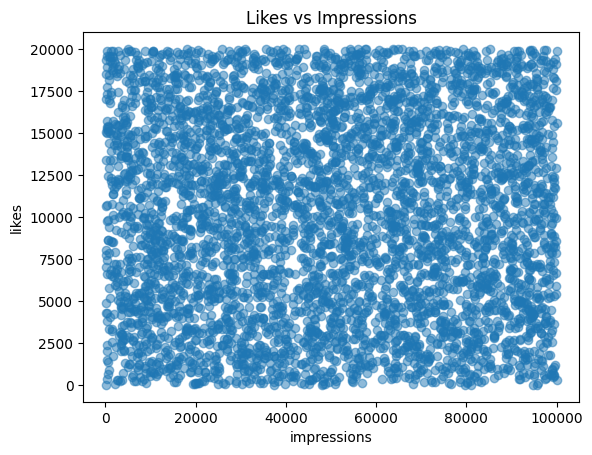

In [ ]:
#Scatter: likes vs impressions
plt.scatter(df['impression_count'],df['likes'],alpha = 0.5)
plt.xlabel('impressions')
plt.ylabel('likes')
plt.title('Likes vs Impressions')
plt.show()

-  Line Plot: daily engagement trend

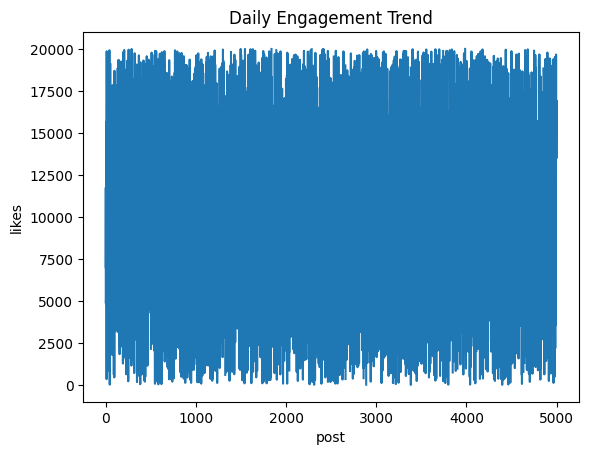

In [ ]:
plt.plot(df['likes'])
plt.xlabel('post')
plt.ylabel('likes')
plt.title('Daily Engagement Trend')
plt.show()

Analysis:

The line plot shows how the number of likes changes across the posts. It helps identify increasing or decreasing trends and unusual fluctuations in engagement.

-  Bar: posts by category

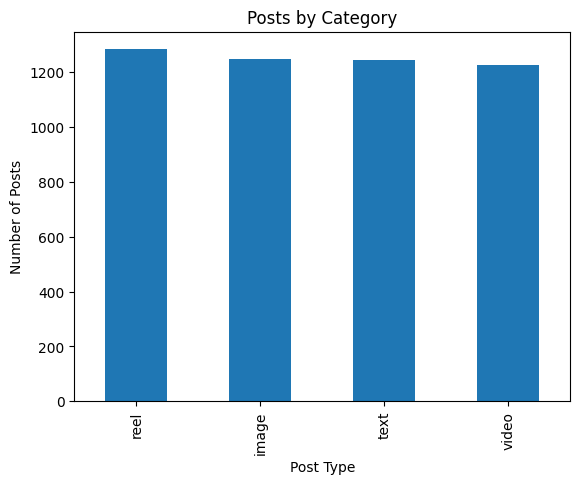

In [ ]:
df['post_type'].value_counts().plot(kind='bar')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')
plt.show()

Analysis

The bar plot shows the number of posts in each post category. It helps us understand which categories have more or fewer posts in the dataset.

- Pie: gender distribution

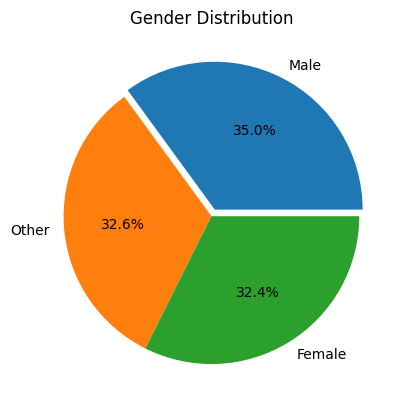

In [ ]:
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%',explode=[0.05, 0, 0])

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

Analysis

The pie chart shows the percentage distribution of different genders in the dataset.The pie chart shows that male users have the highest proportion in the dataset compared with the other gender categories..

- Histogram: age

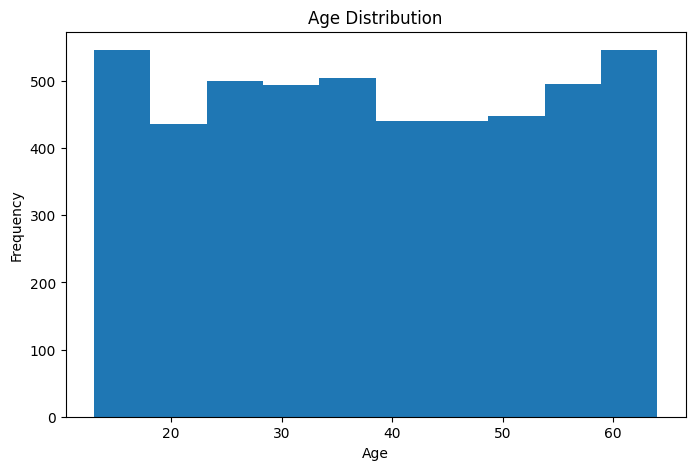

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

Analysis:

Most users are aged 25–35, with another noticeable concentration around 60, while age 20 has relatively fewer users.

- Box: engagement rate

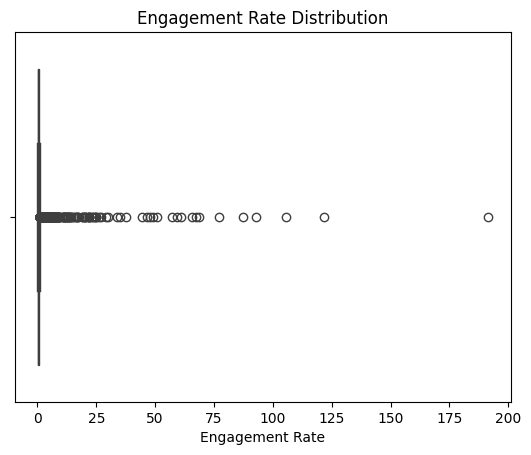

In [ ]:
sns.boxplot(x=df['engagement_rate'])
plt.title('Engagement Rate Distribution')
plt.xlabel('Engagement Rate')
plt.show()

In [ ]:
Q1 = df['engagement_rate'].quantile(0.25)
Q3 = df['engagement_rate'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['engagement_rate'] < lower) |
              (df['engagement_rate'] > upper)]

len(outliers)

578

In [ ]:
df = df[(df['engagement_rate'] >= lower) &
        (df['engagement_rate'] <= upper)]

In [ ]:
df.shape

(4422, 20)

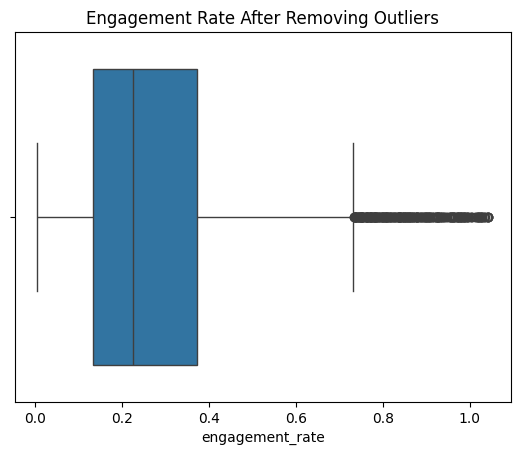

In [ ]:
sns.boxplot(x=df['engagement_rate'])
plt.title('Engagement Rate After Removing Outliers')
plt.show()

**Seaborn**

- Count plot: post type

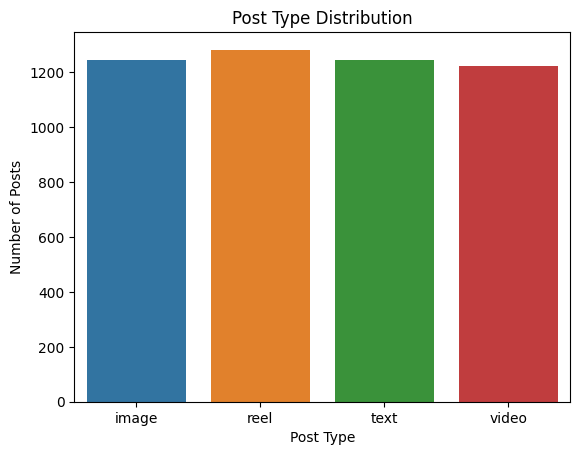

In [18]:
sns.countplot(data=df, x='post_type',hue='post_type')
plt.title('Post Type Distribution')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.show()

Analysis:

Reels have the highest number of posts in the dataset compared with other post types.

-  Bar Plot — Average Likes by Category

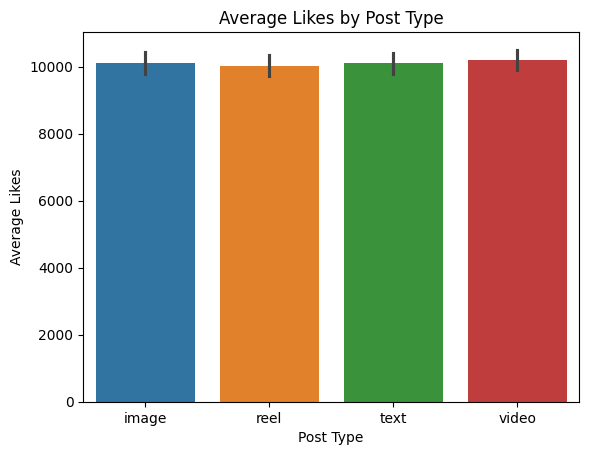

In [17]:
sns.barplot(data=df, x='post_type', y='likes',hue='post_type')
plt.title('Average Likes by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Average Likes')
plt.show()

- Violin Plot — Followers vs Sentiment

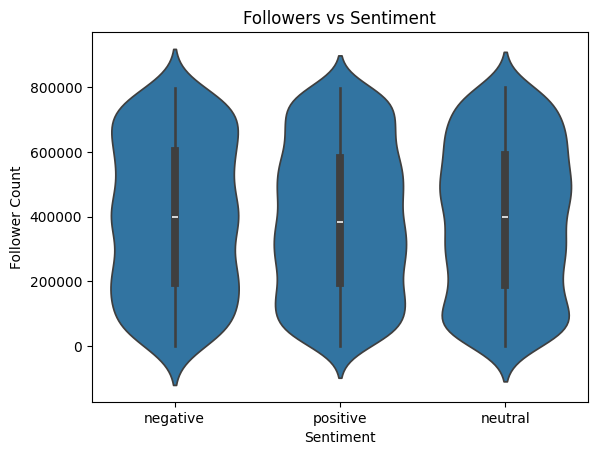

In [ ]:
sns.violinplot(data=df, x='sentiment', y='follower_count')
plt.title('Followers vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.show()

- Heatmap — Correlation Matrix

In [ ]:
num_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec',
            'impression_count', 'follower_count', 'engagement_rate']

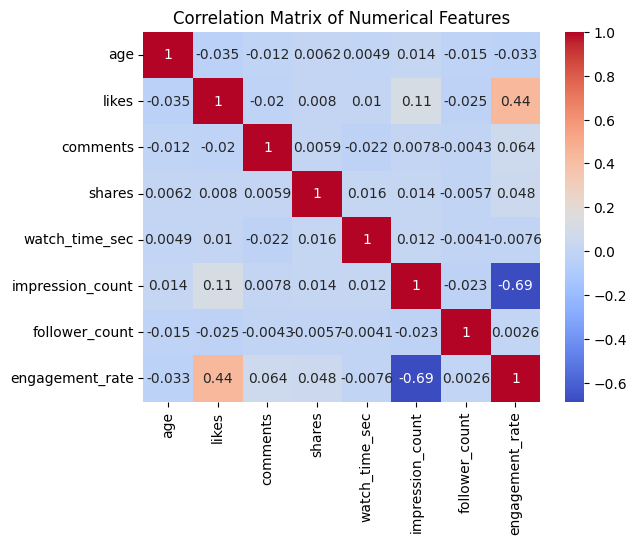

In [ ]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

- Swarm Plot — Engagement vs Device

In [1]:
import warnings
warnings.warn("Device column is not available in the dataset.")

/tmp/ipykernel_2435/193977158.py:2: UserWarning: Device column is not available in the dataset.
  warnings.warn("Device column is not available in the dataset.")


/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 49.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 51.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 49.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 55.8% of the points cannot be plac

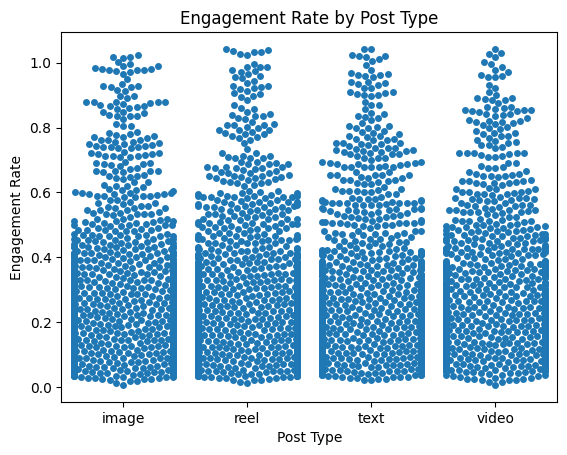

In [ ]:
sns.swarmplot(data=df, x='post_type', y='engagement_rate')
plt.title('Engagement Rate by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Engagement Rate')
plt.show()

**Plotly (Interactive)**


In [21]:
# Line Chart
fig = px.line(df,x='posted_at',y='impression_count',title='Impressions Over Time',color ='posted_at'
)

fig.show()

In [20]:
#Bar Chart
avg_likes = df.groupby('post_type', as_index=False)['likes'].mean()
fig = px.bar(
    avg_likes,
    x='post_type',
    y='likes',
    title='Average Likes by Post Type',
    labels={
        'post_type': 'Post Type',
        'likes': 'Average Likes'

    },
    color='post_type'
)

fig.show()

 ## **Final Insights should include the following analysis:**

**Content Performance**

- ### Which post types have the highest engagement? ###


In [22]:
df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
post_type,
video,1.122365
text,1.064549
image,0.895646
reel,0.783047


Insight:

Video posts have the highest average engagement rate (1.122), followed by text posts (1.065). Image posts have moderate engagement, while reels have the lowest average engagement rate (0.783).

- ### Best-performing content category ###

In [23]:
df.groupby('post_category')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
post_category,
food,1.358628
tech,1.160475
lifestyle,1.091019
music,0.888803
fitness,0.865628
education,0.844222
fashion,0.807109
travel,0.702223


Insight

Food is the best-performing content category, with the highest average engagement rate of 1.359. Tech and lifestyle also show relatively high engagement, while travel has the lowest average engagement rate at 0.702.

- ### Which countries have the highest average engagement rate? ###

In [24]:
df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


insight

Brazil has the highest average engagement rate at 1.54,while the USA has the lowest at 0.577.

**User Trends**

- ### How age affects engagement ###

In [26]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 25, 35, 45, 100],
    labels=['Under 18', '18-25', '26-35', '36-45', '46+']
)
df.groupby('age_group',observed=True)['engagement_rate'].mean()

,engagement_rate
age_group,
Under 18,0.867038
18-25,1.059536
26-35,0.865316
36-45,0.858642
46+,1.078724


Insight:

The 18–25 age group has the highest average engagement rate at 1.059, closely followed by the 46+ group at 1.079. The 36–45 group has the lowest engagement rate at 0.859. Overall, engagement varies across age groups rather than showing a consistent increase or decrease with age.

- ### Performance difference for verified accounts ###

In [28]:
df.groupby('is_verified')['engagement_rate'].mean()

,engagement_rate
is_verified,
False,0.954744
True,1.054250


Insight:

Verified accounts have a higher average engagement rate (1.05) than unverified accounts (0.95).

**Behavioral Insights**

- ### Best time of day for impressions ###

In [43]:
df['hour'] = df['posted_at'].dt.hour
df.groupby('hour')['impression_count'].mean().sort_values(ascending=False)

,impression_count
hour,
0,50013.7328


Insight:

The dataset does not provide enough time variation to determine the best time of day for impressions.

-  ### Device type impact on watch time ###

In [36]:
df.groupby('device_type')['watch_time_sec'].mean()

,watch_time_sec
device_type,
desktop,3974.792521
mobile,4087.830760
tablet,3979.736429


Insight:

Mobile users have the highest average watch time (4,087.83 sec), followed by tablet and desktop users.

**Sentiment Analysis**

- ### Which sentiment performs best ###

In [44]:
df.groupby('sentiment')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.954800


Insight:

Negative posts shows (1.04)lightly higher engagement than neutral posts and positive post.

- ### Behavior of negative/neutral sentiment posts ###

In [45]:
df[df['sentiment'].isin(['negative', 'neutral'])].groupby('sentiment')[
    ['likes', 'comments', 'shares', 'impression_count', 'engagement_rate']
].mean()

,likes,comments,shares,impression_count,engagement_rate
sentiment,,,,,
negative,10211.406452,1516.584402,1007.186966,50191.960417,1.038486
neutral,9917.785570,1529.270525,996.149966,49515.971185,0.991170


Insight:

Negative posts show slightly higher overall engagement than neutral posts, with an engagement rate of 1.038 compared with 0.991.